In [1]:
import os
import sys
import numpy as np
# load files for each season
import pickle
import pandas as pd
sys.path.append('../scripts')
from utils import average_across_days, average_across_days_phiid

# Choose Ecosystem and Metric
ecosystem = 'GulfStLawrence'  # 'GulfStLawrence', 'LaurentianMapleGrove'
metric = 'PhiID'  # 'PLV', 'coherence', 'transfer_entropy', 'wpli', 'imag_coherence'

if ecosystem == 'GulfStLawrence':
    from GulfStLawrence_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names_fr, plant_distances
else:
    from LaurentianMapleGrove_info import seasons, SPRING, SUMMER, FALL, WINTER, plant_common_names_fr, plant_distances

df_all_seasons = []
for SEASON in [SPRING, SUMMER, FALL, WINTER]:
    try:
        with open(f'../plant_data_{ecosystem}/{seasons[SEASON]}/connectivity_results_{metric}_tau100_kindgaussian_redMMI.pkl', 'rb') as f:
            dfs_results = pickle.load(f)
            if metric == 'PhiID':
                df_combined, df_avg = average_across_days_phiid(dfs_results)
                #df_avg = df_combined.groupby(["date", "Epoch", "Plant1", "Plant2"], as_index=False)['xtx'].mean()
            else:
                df_combined, df_avg = average_across_days(dfs_results, metric=metric)
                df_avg = df_combined.groupby(["date", "Epoch", "Plant1", "Plant2"], as_index=False)[metric].mean()
            
            df_avg["Season"] = SEASON
            df_all_seasons.append(df_avg)
    except FileNotFoundError:
        print(f"File not found for season {seasons[SEASON]}. Skipping...")
        continue

# Sum transfer entropy at each epoch for each season
df_all_seasons_combined = pd.concat(df_all_seasons, ignore_index=True)

# Convert epochs to hours
total_epochs = df_all_seasons_combined["Epoch"].max() + 1  # Assuming epochs span 24 hours
df_all_seasons_combined["Hour"] = df_all_seasons_combined["Epoch"] / total_epochs * 24

if "Season_mapped" not in df_all_seasons_combined.columns:
    df_all_seasons_combined["Season_mapped"] = df_all_seasons_combined["Season"].map(seasons)

season_colors = {
    human_name: color
    for (_, human_name), color in zip(seasons.items(),
                                      ["#2ca02c", "#ffcc00", "#ff7f0e", "#1f77b4"])
}
plant_names = {i: name for i, name in enumerate(plant_common_names_fr.values())}

In [ ]:
import os
import pandas as pd
import zipfile

exclude_features = {"Daily amplitudes", "Traces", "Pbi"}
base_path = f'../plant_data_{ecosystem}'

def load_grow_wave_csvs(grow_wave_folder):
    dfs = []
    columns_to_keep = ['timestamp', 'mean_gw', 'std_gw', 'gw_upper_limit', 'gw_lower_limit']
    for i in range(1, 9):
        folder_path = os.path.join(grow_wave_folder, str(i))
        if not os.path.isdir(folder_path):
            print(f"Missing folder: {folder_path}")
            continue
        zip_files = [f for f in os.listdir(folder_path) if f.endswith('.zip')]
        if not zip_files:
            print(f"No zip found in {folder_path}")
            continue
        zip_path = os.path.join(folder_path, zip_files[0])
        with zipfile.ZipFile(zip_path, "r") as zf:
            csv_names = [f for f in zf.namelist() if f.endswith('.csv')]
            if not csv_names:
                print(f"No CSV in zip: {zip_path}")
                continue
            csv_name = csv_names[0]
            zf.extract(csv_name, folder_path)
            csv_path = os.path.join(folder_path, csv_name)
            df = pd.read_csv(csv_path, sep=None, engine='python')
            # Only keep selected columns
            missing = [col for col in columns_to_keep if col not in df.columns]
            if missing:
                print(f"Warning: {csv_path} missing columns: {missing}")
                continue
            df = df[columns_to_keep]
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["rounded_time"] = df["timestamp"].apply(round_to_nearest_10min)
            df["plant"] = i
            dfs.append(df)
    if dfs:
        feature_df = pd.concat(dfs, ignore_index=True)
    else:
        feature_df = pd.DataFrame()
    return feature_df


def round_to_nearest_10min(dt):
    # dt is a pandas.Timestamp
    discard = dt.minute % 10
    dt -= pd.Timedelta(minutes=discard, seconds=dt.second, microseconds=dt.microsecond)
    if discard >= 5:
        dt += pd.Timedelta(minutes=10)
    return dt

def process_season(serie, season_folder):
    folderpath = os.path.join(base_path, season_folder)
    matching_folders = [d for d in os.listdir(folderpath) if d.startswith(serie)]
    if not matching_folders:
        raise FileNotFoundError(f"No folder starting with {serie} in {folderpath}")
    serie_folder = matching_folders[0]
    serie_path = os.path.join(folderpath, serie_folder)

    features_of_interest = [
        d for d in os.listdir(serie_path)
        if os.path.isdir(os.path.join(serie_path, d)) and d not in exclude_features
    ]
    print(f"Detected features in {serie_path}: {features_of_interest}")

    dfs = []
    for feat in features_of_interest:
        all_feature = []
        feat_path = os.path.join(serie_path, feat)
        if feat == "Grow wave":
            feature_df = load_grow_wave_csvs(feat_path)
            if not feature_df.empty:
                dfs.append(feature_df)
            continue
        if not os.path.isdir(feat_path):
            continue

        for file in os.listdir(feat_path):
            if file.endswith(".zip"):
                with zipfile.ZipFile(os.path.join(feat_path, file), "r") as zip_ref:
                    zip_ref.extractall(feat_path)

        csv_files = [f for f in os.listdir(feat_path) if f.endswith(".csv")]
        for csv in csv_files:
            plant_number = csv.split('-')[1]
            csv_path = os.path.join(feat_path, csv)
            df = pd.read_csv(csv_path, sep=None, engine='python')
            pred_col = "prediction" if "prediction" in df.columns else "predictions"
            df["timestamp"] = pd.to_datetime(df["timestamp"])
            df["rounded_time"] = df["timestamp"].apply(round_to_nearest_10min)
            df = df.rename(columns={pred_col: feat})
            df["plant"] = int(plant_number)
            all_feature.append(df[["rounded_time", "plant", feat]])

        if all_feature:
            feature_df = pd.concat(all_feature, ignore_index=True)
            dfs.append(feature_df)

    from functools import reduce
    if not dfs:
        print(f"No dataframes collected for season: {season_folder}")
        return pd.DataFrame()

    df_merged = reduce(lambda left, right: pd.merge(left, right, on=["rounded_time", "plant"], how="outer"), dfs)

    df_merged["date"] = df_merged["rounded_time"].dt.date
    df_merged["hour_decimal"] = df_merged["rounded_time"].dt.hour + df_merged["rounded_time"].dt.minute / 60
    df_merged = df_merged.sort_values(["plant", "rounded_time"])
    return df_merged

# ---- Usage Example ----
# seasons = {"Serie 6": "Spring 2024", ...}  # Your mapping


# Now, dfs_by_season[season_folder] gives you the rounded and merged DataFrame!


In [4]:
def hourly_aggregate(df):
    # Ensure datetime format
    df['hour'] = df['rounded_time'].dt.floor('h')
    agg_columns = [col for col in df.columns if col not in ['rounded_time', 'date', 'hour_decimal', 'hour']]
    df_hourly = (
        df.groupby(['date', 'plant', 'hour'], as_index=False)[agg_columns]
          .mean(numeric_only=True)
    )
    # Add back hour_decimal if you want
    df_hourly['hour_decimal'] = df_hourly['hour'].dt.hour.astype(float)
    return df_hourly

dfs_by_season = {}
for serie, season_folder in seasons.items():
    print(f"Processing {serie} / {season_folder}")
    df_season = process_season(serie, season_folder)
    # Apply the aggregation
    df_season_hourly = hourly_aggregate(df_season)
    dfs_by_season[season_folder] = df_season_hourly




Processing Serie 6 / Spring 2024
Detected features in ../plant_data_GulfStLawrence\Spring 2024\Serie 6 5min 2024-06-07 au 2024-06-14: ['Calcium deficit', 'Drought h1', 'Drought ssp', 'Drought wsp', 'Fungal infection', 'General stress', 'Grow wave', 'Iron deficit', 'Nitrogen deficit', 'Phosphorus deficit', 'Potassium deficit']


KeyError: "['Grow wave'] not in index"

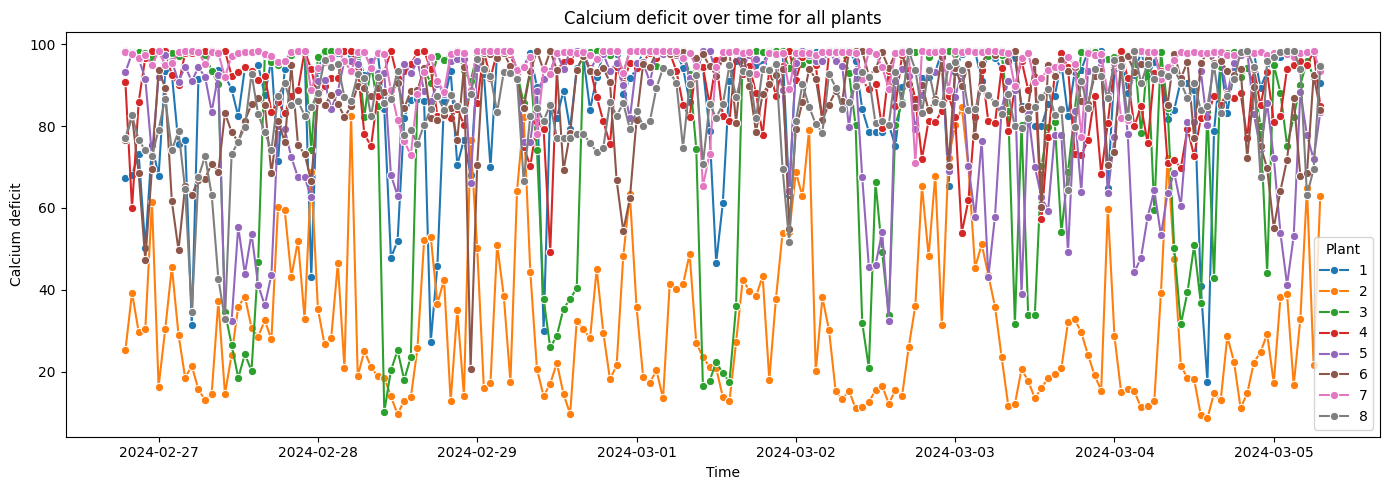

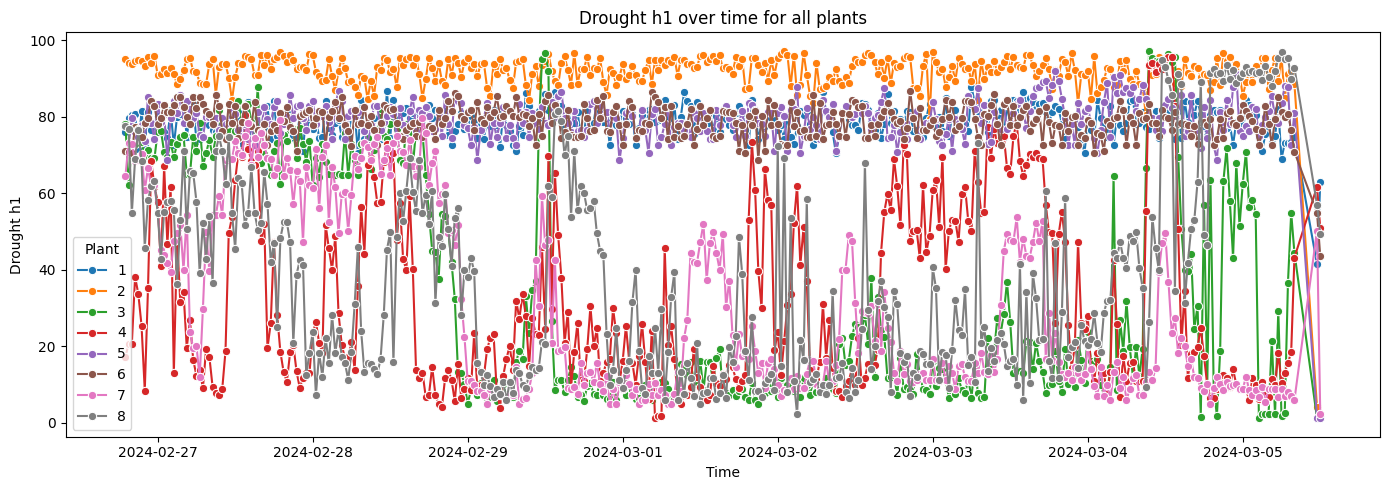

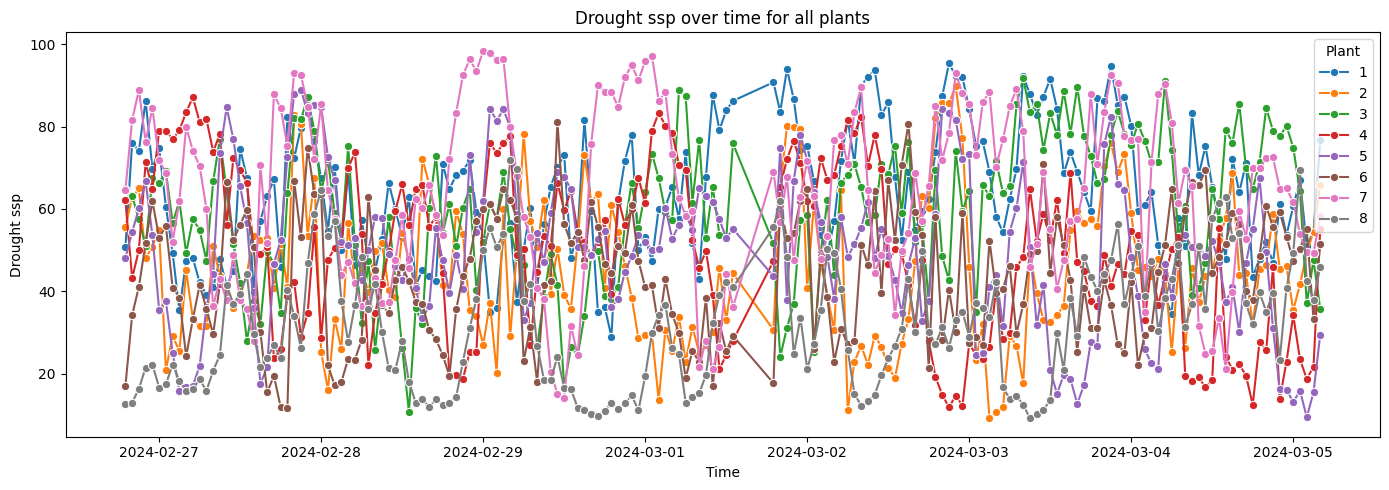

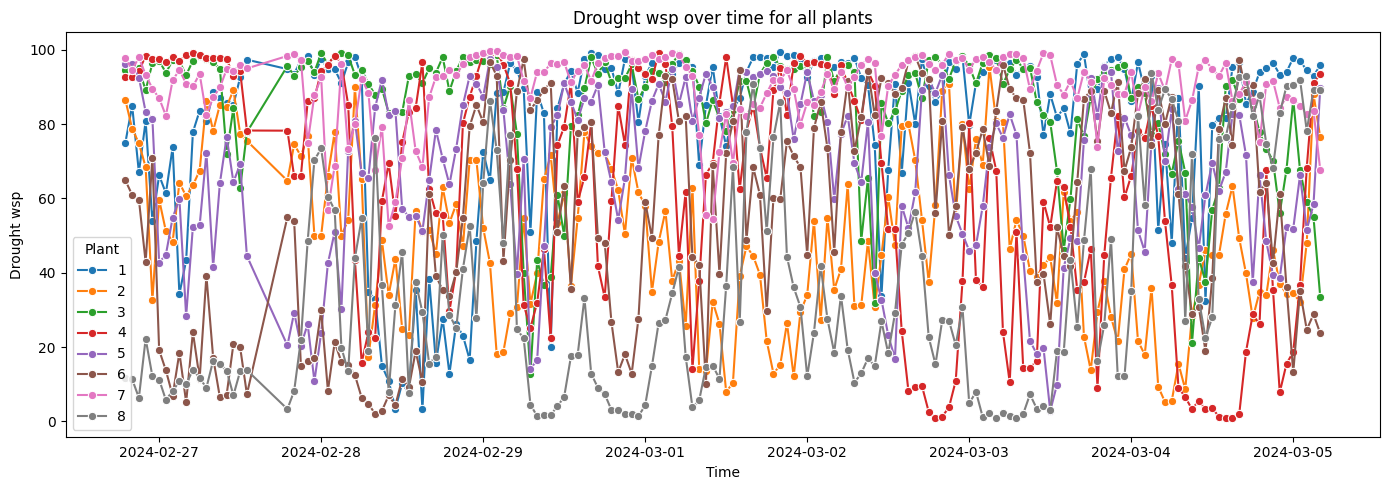

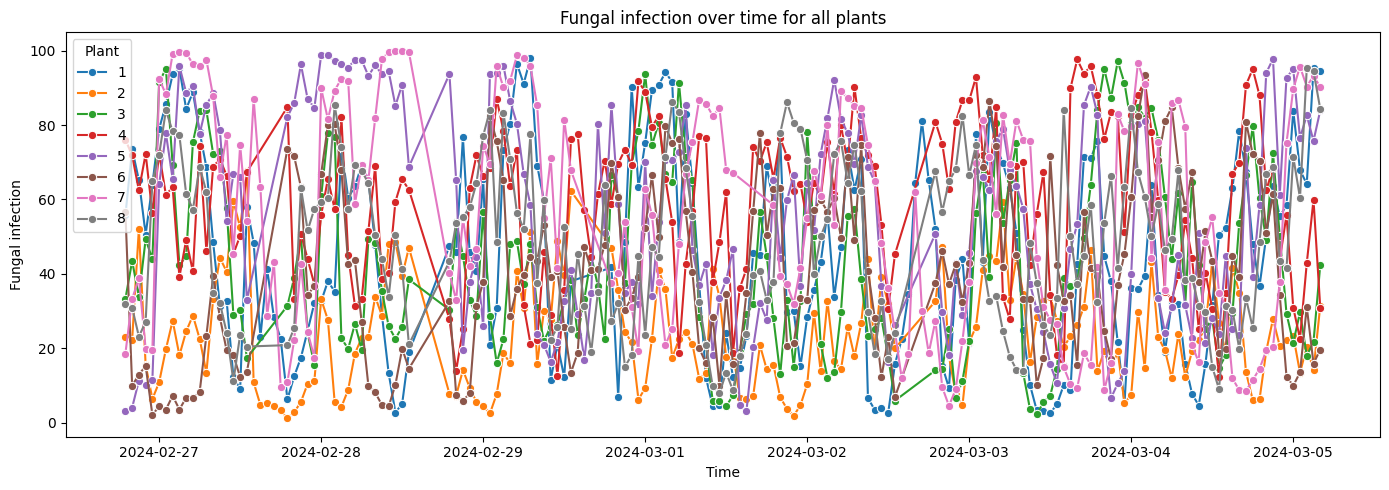

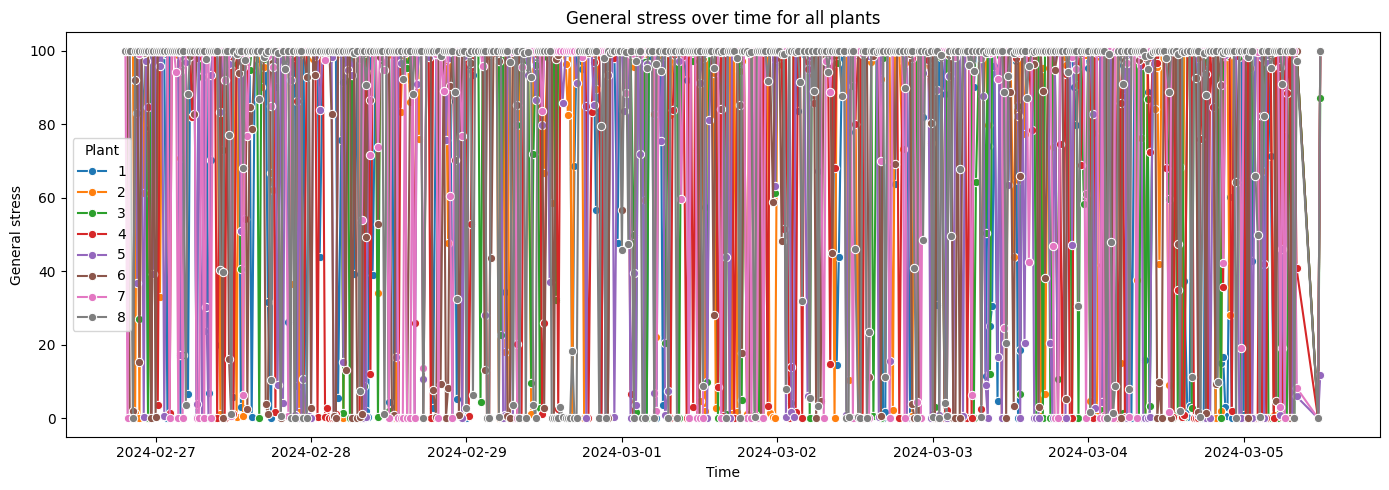

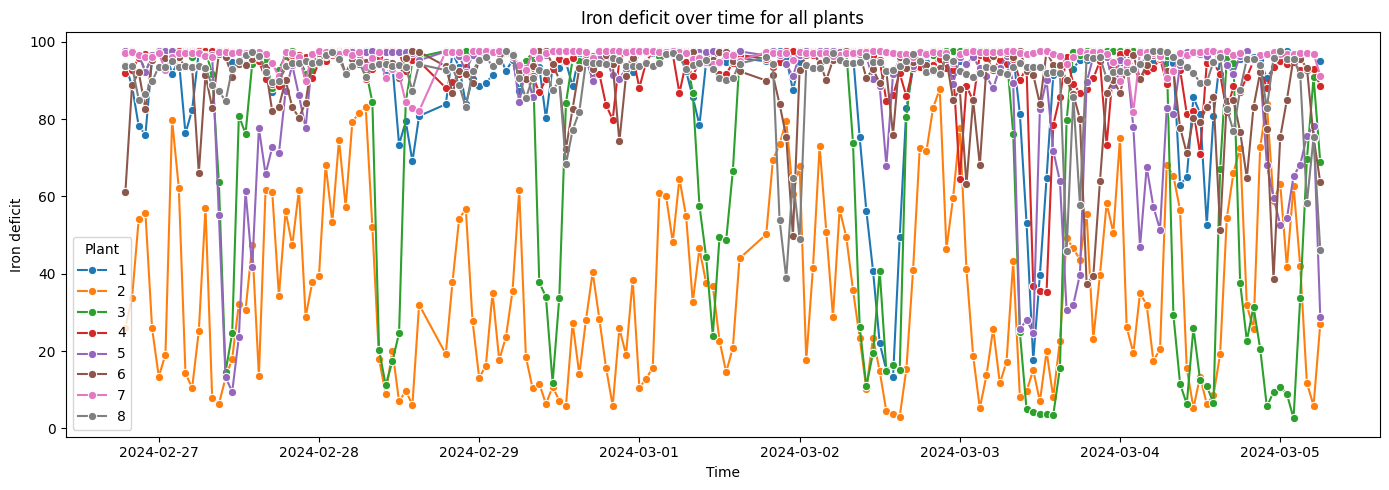

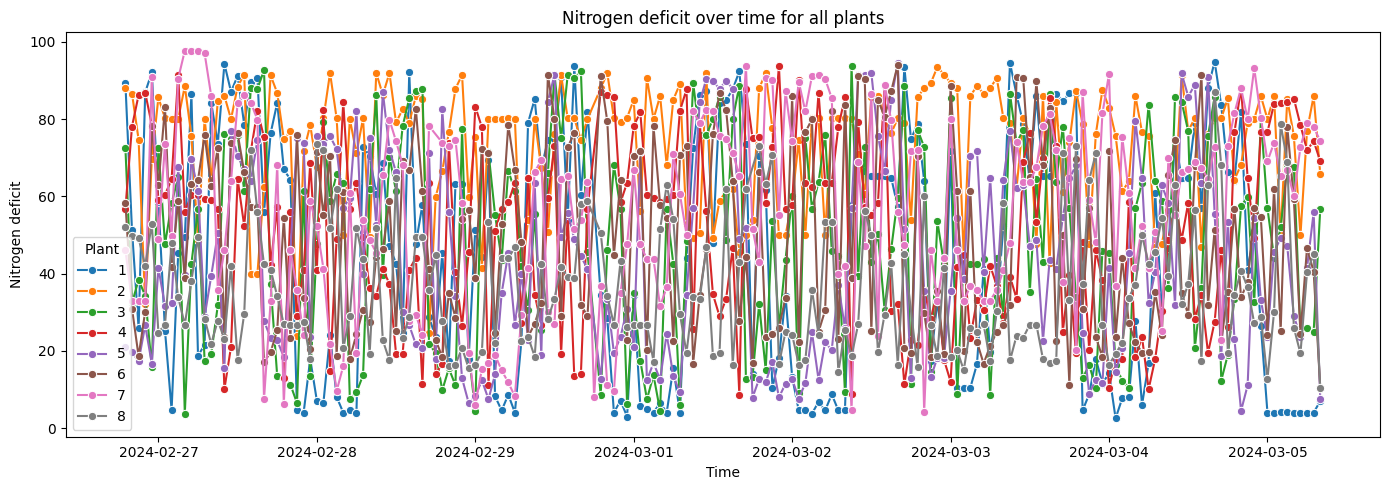

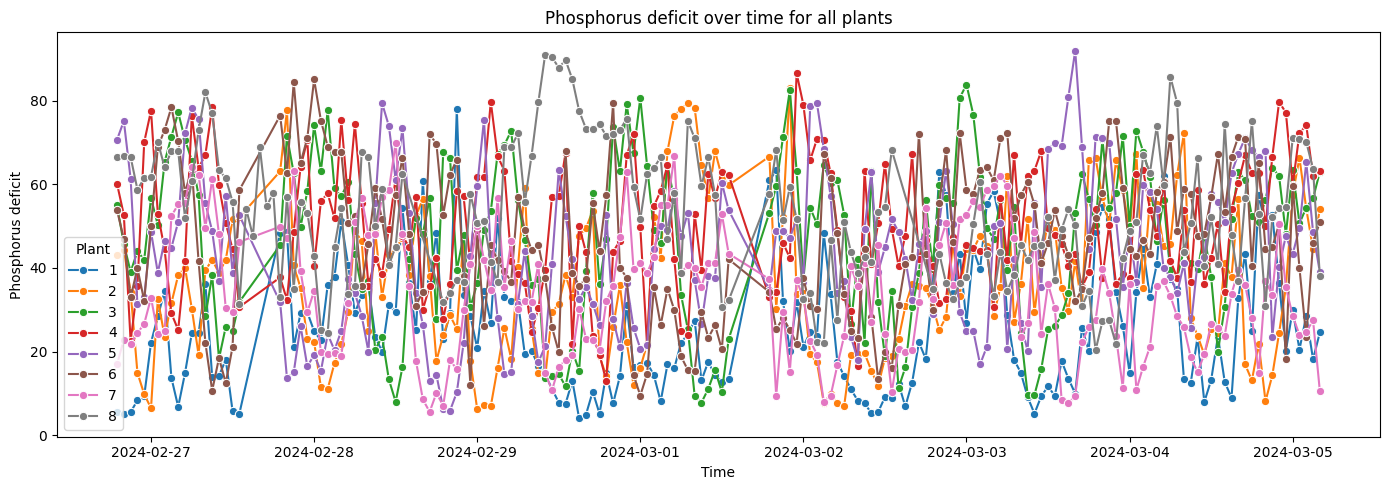

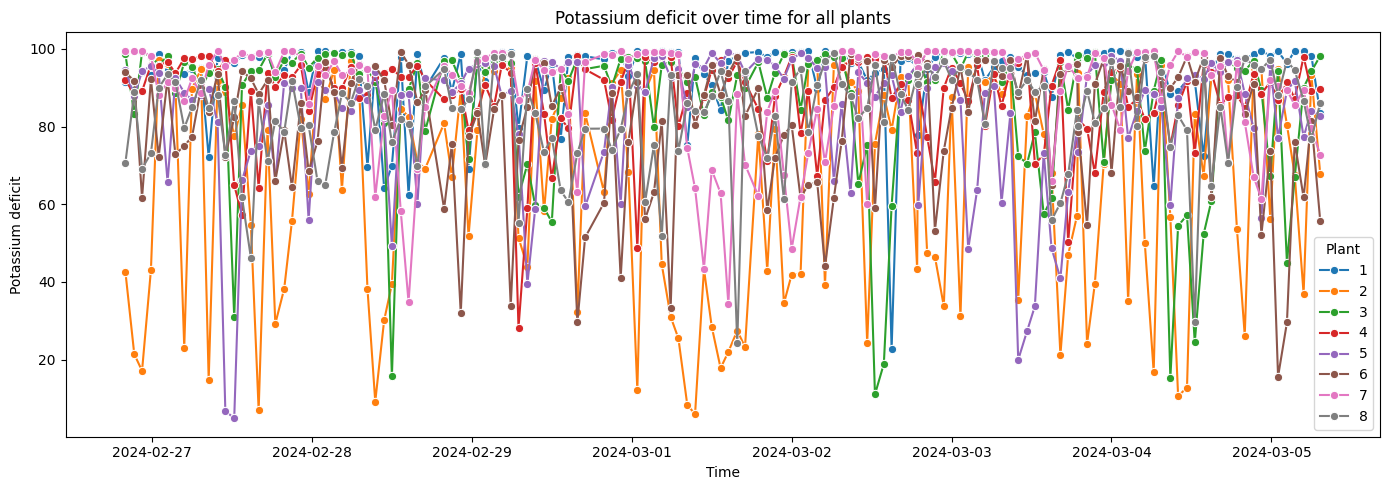

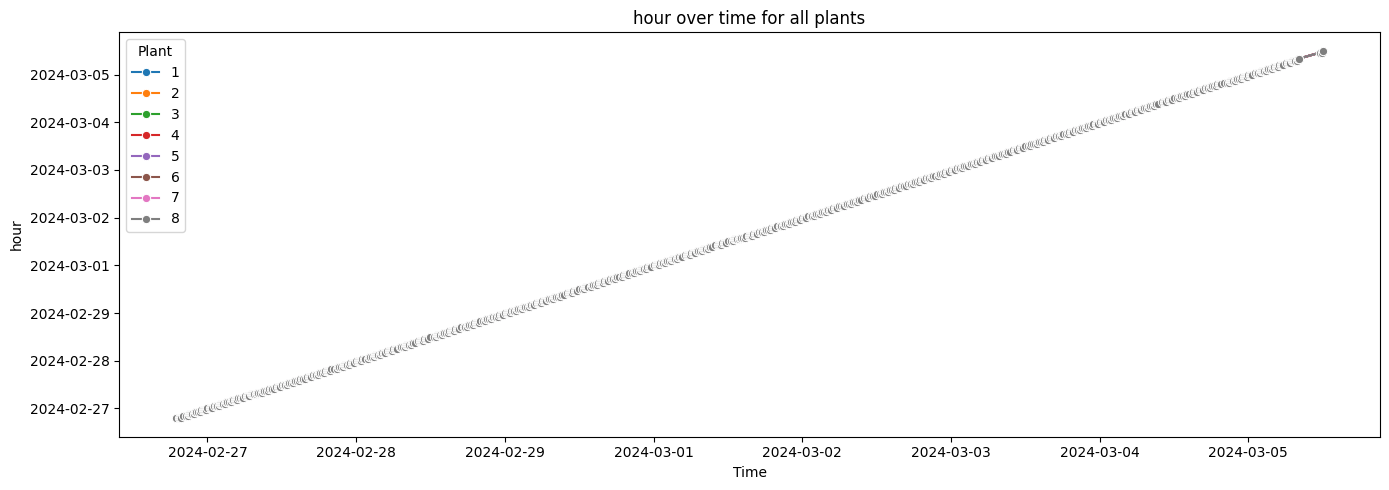

In [192]:
import seaborn as sns
import matplotlib.pyplot as plt

# Get all feature columns (exclude non-feature columns)
non_feature_cols = {"rounded_time", "plant", "date", "hour_decimal"}
feature_cols = [col for col in df_season.columns if col not in non_feature_cols]

for feature in feature_cols:
    plt.figure(figsize=(14, 5))
    sns.lineplot(data=df_season, x="rounded_time", y=feature, hue="plant", marker="o", palette="tab10")
    plt.xlabel("Time")
    plt.ylabel(feature)
    plt.title(f"{feature} over time for all plants")
    plt.legend(title="Plant")
    plt.tight_layout()
    plt.show()



Features unique hours: [19 20 21 22 23  0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18]
TE unique hours: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24]
Features unique dates: [datetime.date(2024, 2, 26) datetime.date(2024, 2, 27)
 datetime.date(2024, 2, 28) datetime.date(2024, 2, 29)
 datetime.date(2024, 3, 1) datetime.date(2024, 3, 2)
 datetime.date(2024, 3, 3) datetime.date(2024, 3, 4)
 datetime.date(2024, 3, 5)]
TE unique dates: [datetime.date(2024, 2, 27) datetime.date(2024, 2, 28)
 datetime.date(2024, 2, 29) datetime.date(2024, 3, 1)
 datetime.date(2024, 3, 2) datetime.date(2024, 3, 3)
 datetime.date(2024, 3, 4)]
Features unique plants: [0 1 2 3 4 5 6 7]
TE unique plants: [2 4 5 6 7 0 1 3]
Merged shape: (1104, 15)
transfer_entropy
Computing correlation for plant 0 and metric Phosphorus deficit
transfer_entropy
Computing correlation for plant 0 and metric Calcium deficit
transfer_entropy
Computing correlation for plant 0 and metric Drought h

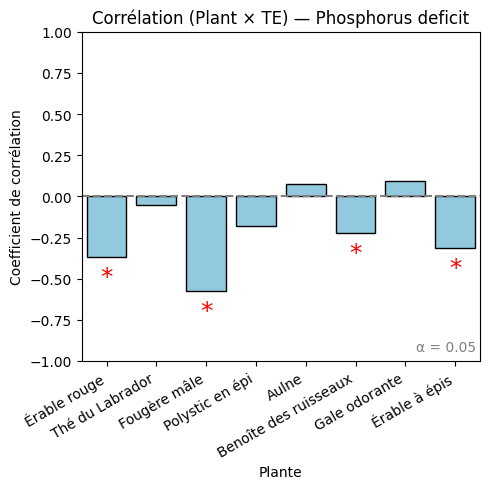

               plant_name  correlation          pval  n_points  FDR_reject
1            Érable rouge    -0.494090  3.106692e-10       144        True
11        Thé du Labrador    -0.249614  2.551433e-03       144        True
21           Fougère mâle    -0.656097  4.161050e-16       120        True
31        Polystic en épi     0.170293  9.715438e-02        96       False
41                  Aulne    -0.058026  4.549941e-01       168       False
51  Benoîte des ruisseaux     0.028899  7.100021e-01       168       False
61          Gale odorante    -0.243519  1.468552e-03       168        True
71          Érable à épis     0.085317  4.085278e-01        96       False


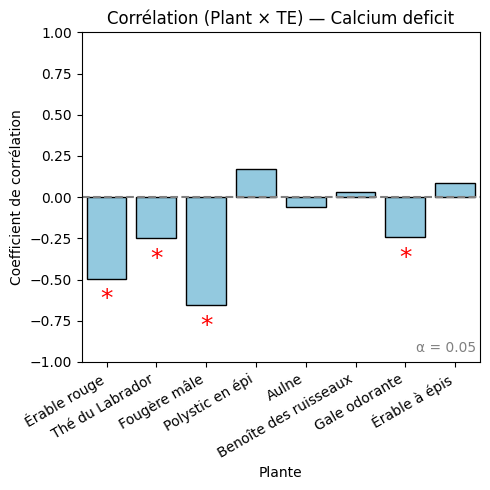

               plant_name  correlation          pval  n_points  FDR_reject
2            Érable rouge     0.070473  4.012746e-01       144       False
12        Thé du Labrador     0.252524  2.261714e-03       144        True
22           Fougère mâle     0.472074  5.234642e-08       120        True
32        Polystic en épi     0.003690  9.715395e-01        96       False
42                  Aulne    -0.122356  1.141031e-01       168       False
52  Benoîte des ruisseaux    -0.055145  4.777254e-01       168       False
62          Gale odorante     0.616923  5.380491e-19       168        True
72          Érable à épis    -0.120374  2.427152e-01        96       False


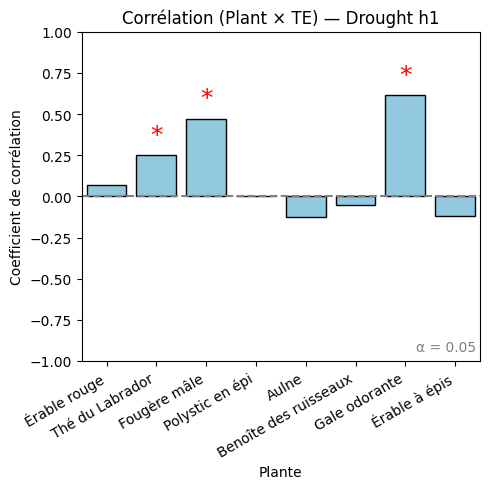

               plant_name  correlation      pval  n_points  FDR_reject
3            Érable rouge     0.087596  0.305183       139       False
13        Thé du Labrador    -0.040417  0.636639       139       False
23           Fougère mâle    -0.241782  0.009235       115        True
33        Polystic en épi     0.184482  0.071964        96       False
43                  Aulne    -0.005988  0.939528       163       False
53  Benoîte des ruisseaux     0.016343  0.835959       163       False
63          Gale odorante    -0.268426  0.000531       163        True
73          Érable à épis     0.228667  0.029245        91       False


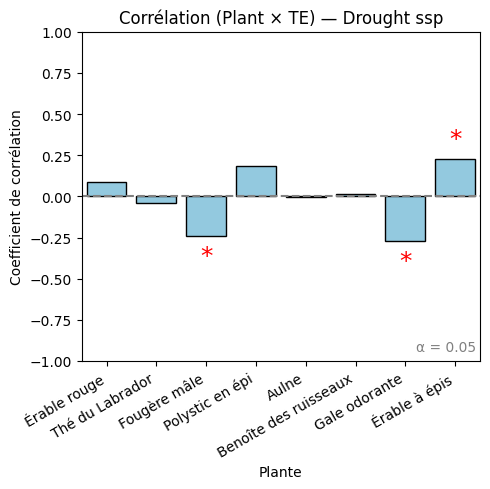

               plant_name  correlation          pval  n_points  FDR_reject
4            Érable rouge    -0.321501  8.521749e-05       144        True
14        Thé du Labrador     0.007769  9.263700e-01       144       False
24           Fougère mâle    -0.482214  4.846909e-08       115        True
34        Polystic en épi     0.093313  3.658518e-01        96       False
44                  Aulne     0.013880  8.604109e-01       163       False
54  Benoîte des ruisseaux    -0.065409  4.067928e-01       163       False
64          Gale odorante    -0.274575  3.896817e-04       163        True
74          Érable à épis     0.282131  6.739935e-03        91        True


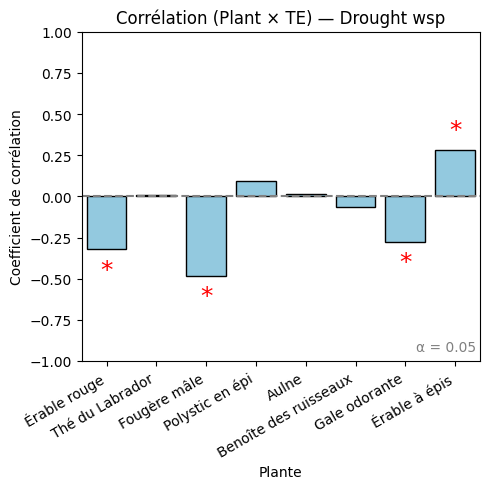

               plant_name  correlation          pval  n_points  FDR_reject
5            Érable rouge    -0.259138  2.499047e-03       134        True
15        Thé du Labrador    -0.035135  6.926230e-01       129       False
25           Fougère mâle    -0.395148  3.023553e-05       105        True
35        Polystic en épi    -0.192603  7.562269e-02        86       False
45                  Aulne    -0.199225  1.355423e-02       153        True
55  Benoîte des ruisseaux    -0.391725  5.522424e-07       153        True
65          Gale odorante     0.090845  2.640834e-01       153       False
75          Érable à épis    -0.237323  2.779493e-02        86       False


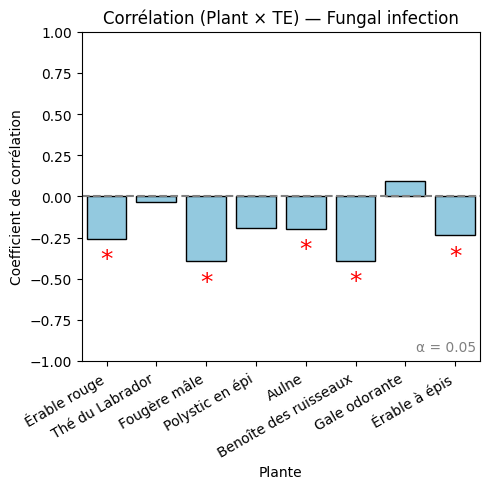

               plant_name  correlation      pval  n_points  FDR_reject
6            Érable rouge     0.083538  0.319511       144       False
16        Thé du Labrador    -0.051475  0.540060       144       False
26           Fougère mâle     0.011292  0.902573       120       False
36        Polystic en épi     0.062588  0.544649        96       False
46                  Aulne     0.231751  0.002506       168        True
56  Benoîte des ruisseaux    -0.011437  0.883023       168       False
66          Gale odorante    -0.162826  0.034962       168       False
76          Érable à épis     0.251180  0.013567        96        True


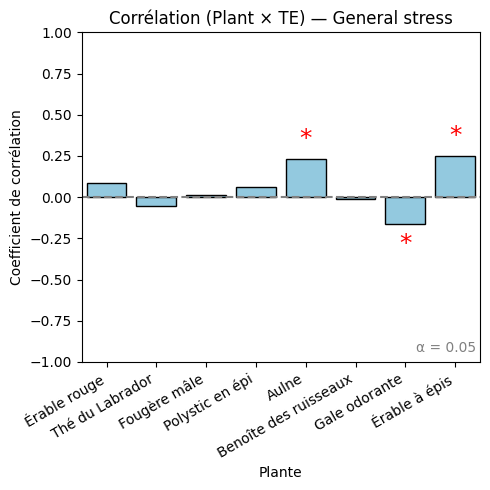

               plant_name  correlation          pval  n_points  FDR_reject
7            Érable rouge    -0.563198  6.448733e-13       138        True
17        Thé du Labrador    -0.155235  6.905733e-02       138       False
27           Fougère mâle    -0.713101  5.549738e-19       114        True
37        Polystic en épi     0.205180  4.849917e-02        93       False
47                  Aulne     0.081795  3.007826e-01       162       False
57  Benoîte des ruisseaux     0.063962  4.187274e-01       162       False
67          Gale odorante    -0.185539  1.808846e-02       162        True
77          Érable à épis    -0.184636  8.148490e-02        90       False


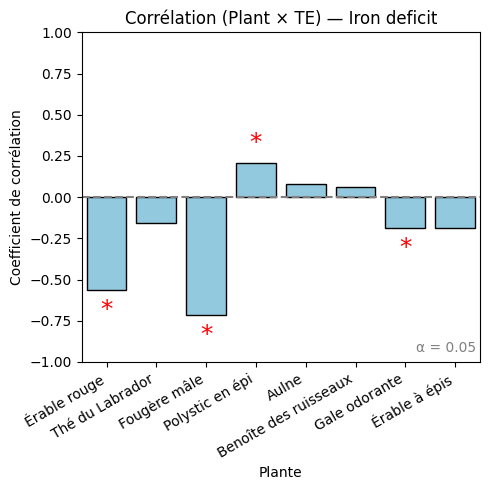

               plant_name  correlation      pval  n_points  FDR_reject
8            Érable rouge     0.391536  0.000001       143        True
18        Thé du Labrador    -0.106110  0.207193       143       False
28           Fougère mâle     0.361922  0.000049       120        True
38        Polystic en épi     0.075216  0.466402        96       False
48                  Aulne     0.246090  0.001347       167        True
58  Benoîte des ruisseaux     0.206588  0.007393       167        True
68          Gale odorante     0.180849  0.019344       167        True
78          Érable à épis    -0.036974  0.723485        94       False


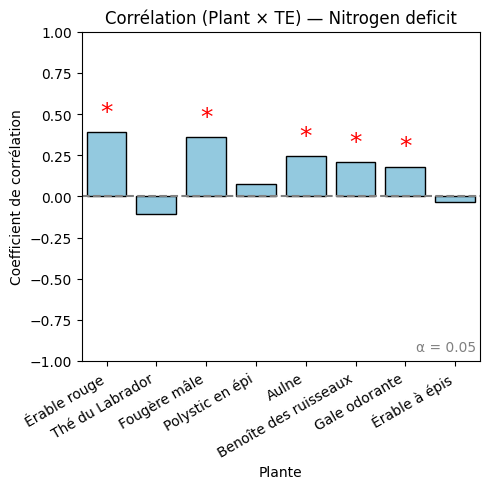

               plant_name  correlation          pval  n_points  FDR_reject
9            Érable rouge    -0.400117  1.030334e-05       114        True
19        Thé du Labrador    -0.117932  2.114235e-01       114       False
29           Fougère mâle    -0.570143  1.630282e-09        95        True
39        Polystic en épi     0.260461  2.127340e-02        78        True
49                  Aulne    -0.006871  9.374360e-01       133       False
59  Benoîte des ruisseaux     0.257445  2.775491e-03       133        True
69          Gale odorante    -0.131043  1.327123e-01       133       False
79          Érable à épis     0.092404  4.368405e-01        73       False


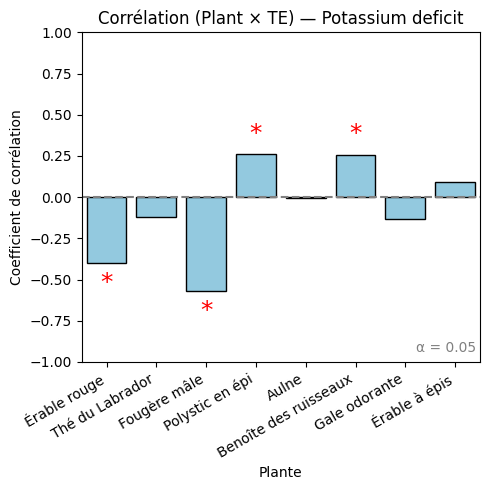

In [193]:
import numpy as np
import pandas as pd

season = "Winter 2024"  # or "Summer 2024", etc

te_season = df_all_seasons_combined[df_all_seasons_combined['Season_mapped'] == season].copy()
te_season["hour"] = te_season["Hour"].round().astype(int)

te1 = (
    te_season
    .groupby(['date', 'Plant1', 'hour'])[metric]
    .mean()
    .reset_index()
    .rename(columns={"Plant1": "plant"})
)
te2 = (
    te_season
    .groupby(['date', 'Plant2', 'hour'])[metric]
    .mean()
    .reset_index()
    .rename(columns={"Plant2": "plant"})
)

te_hourly = pd.merge(
    te1, te2, on=['date', 'plant', 'hour'], how='outer', suffixes=('_as_plant1', '_as_plant2')
)
te_hourly[metric] = te_hourly[[f"{metric}_as_plant1", f"{metric}_as_plant2"]].mean(axis=1)
te_hourly = te_hourly[['date', 'plant', 'hour', metric]]

df_features = dfs_by_season[season]
df_features['plant'] = df_features['plant'] - 1
df_features['hour'] = df_features['hour_decimal'].astype(int)
te_hourly['hour'] = te_hourly['hour'].astype(int)
df_features['plant'] = df_features['plant'].astype(int)
te_hourly['plant'] = te_hourly['plant'].astype(int)
df_features['date'] = pd.to_datetime(df_features['date']).dt.date
te_hourly['date'] = pd.to_datetime(te_hourly['date']).dt.date

print("\nFeatures unique hours:", df_features['hour'].unique())
print("TE unique hours:", te_hourly['hour'].unique())
print("Features unique dates:", df_features['date'].unique())
print("TE unique dates:", te_hourly['date'].unique())
print("Features unique plants:", df_features['plant'].unique())
print("TE unique plants:", te_hourly['plant'].unique())


merged = pd.merge(
    df_features,
    te_hourly[['date', 'plant', 'hour', metric]],
    on=['date', 'plant', 'hour']
)
print("Merged shape:", merged.shape)



metrics = [
    "Phosphorus deficit", "Calcium deficit", "Drought h1", "Drought ssp", "Drought wsp",
    "Fungal infection", "General stress", "Iron deficit", "Nitrogen deficit", "Potassium deficit"
]

from scipy.stats import pearsonr, spearmanr
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

def compute_corrs(merged, metrics, plant_names, method='pearson'):
    corr_results = []
    for plant in sorted(merged['plant'].unique()):
        plant_data = merged[merged['plant'] == plant]
        for metric_ in metrics:
            print(metric)
            sub = plant_data[[metric, metric_]].dropna()
            if len(sub) > 1:
                print(f"Computing correlation for plant {plant} and metric {metric_}")
                
                if method == 'pearson':
                    corr, pval = pearsonr(sub[metric], sub[metric_])
                else:
                    corr, pval = spearmanr(sub[metric], sub[metric_])
            else:
                corr, pval = np.nan, np.nan
            corr_results.append({
                'plant': plant,
                'plant_name': plant_names.get(plant, str(plant)),
                'metric': metric_,
                'correlation': corr,
                'pval': pval,
                'n_points': len(sub)
            })
    return pd.DataFrame(corr_results)

import seaborn as sns

def plot_corrs(corr_df, metric, alpha=0.05):
    df_metric = corr_df[corr_df['metric'] == metric].copy()
    df_metric = df_metric.sort_values('plant')
    print(df_metric[['plant_name','correlation','pval','n_points','FDR_reject']])
    # significance star (asterisk) if p < alpha
    stars = df_metric['pval'].apply(lambda p: '*' if p < alpha else '')
    
    plt.figure(figsize=(5,5))
    ax = sns.barplot(x='plant_name', y='correlation', data=df_metric, color='skyblue', edgecolor='k')
    plt.axhline(0, color='gray', linestyle='--')
    plt.ylim(-1, 1)
    plt.title(f"Corrélation (Plant × TE) — {metric}")
    plt.ylabel("Coefficient de corrélation")
    plt.xlabel("Plante")
    plt.xticks(rotation=30, ha='right')
    
    # add significance stars
    for idx, (bar, star, corr) in enumerate(zip(ax.patches, stars, df_metric['correlation'])):
        if star:
            ax.text(bar.get_x() + bar.get_width()/2, corr + np.sign(corr)*0.05, star,
                    ha='center', va='bottom' if corr > 0 else 'top', color='red', fontsize=18)
    
    # annotation for method and alpha
    plt.text(0.99, 0.02, f"α = {alpha}", ha='right', va='bottom', fontsize=10,
             color='gray', transform=plt.gca().transAxes)
    plt.tight_layout()
    plt.show()

metrics = [
    "Phosphorus deficit", "Calcium deficit", "Drought h1", "Drought ssp", "Drought wsp",
    "Fungal infection", "General stress", "Iron deficit", "Nitrogen deficit", "Potassium deficit"
]

# Compute (method='pearson' or 'spearman')
corr_df = compute_corrs(merged, metrics, plant_names, method='spearman')
from statsmodels.stats.multitest import multipletests

# All p-values for all (plant, metric) pairs
corr_df['FDR_reject'], corr_df['pval_FDR'], _, _ = multipletests(
    corr_df['pval'].values,
    alpha=0.05,
    method='fdr_bh'
)
# Plot for all metrics
for metric_ in metrics:
    plot_corrs(corr_df, metric_, alpha=0.05)


In [197]:
seasons

{'Serie 3': 'Spring 2024',
 'Serie 29': 'Summer 2024',
 'Serie 36': 'Fall 2024',
 'Serie 2': 'Winter 2024'}

METRIC transfer_entropy
METRIC transfer_entropy
METRIC transfer_entropy
METRIC transfer_entropy


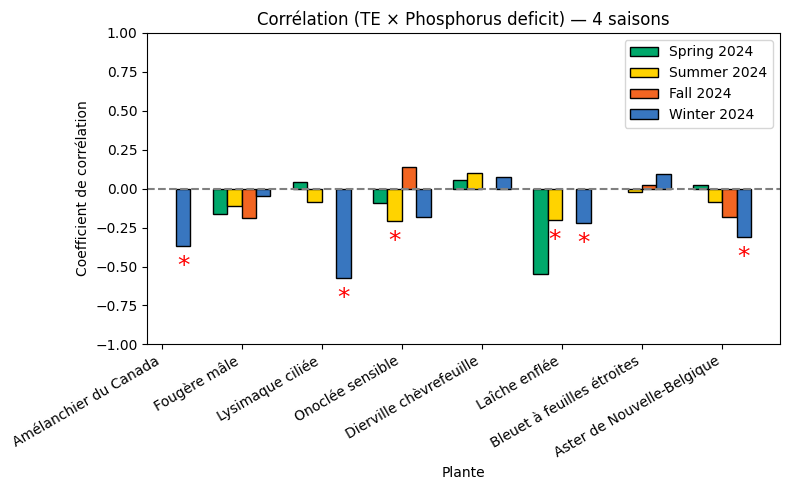

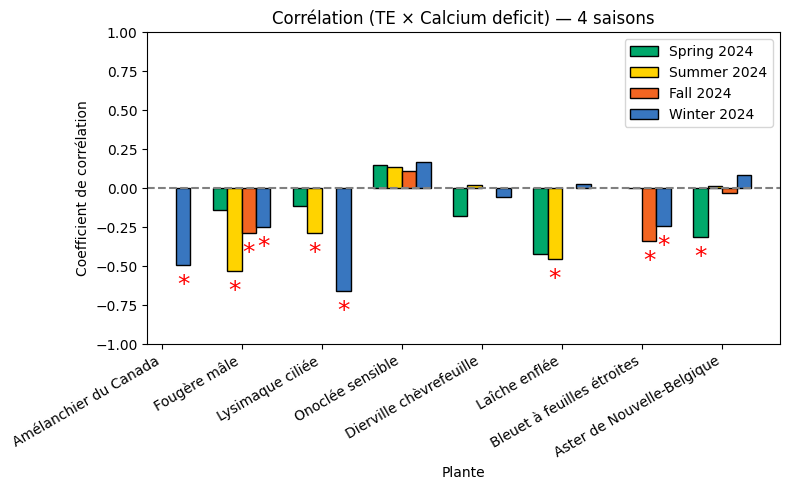

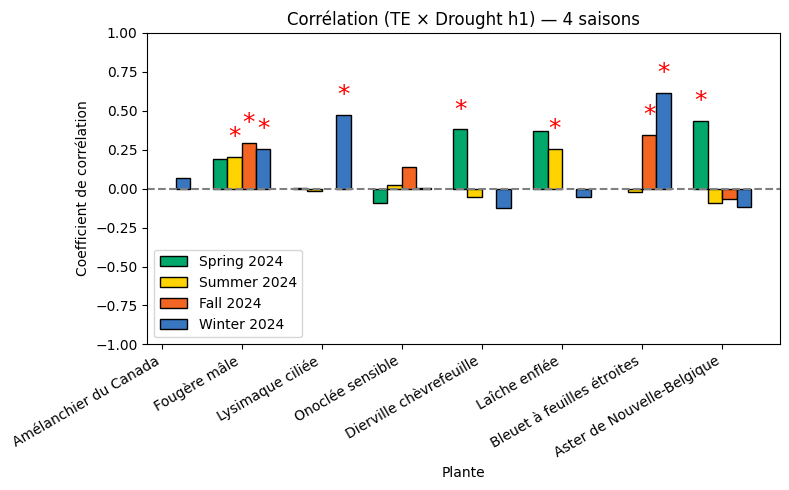

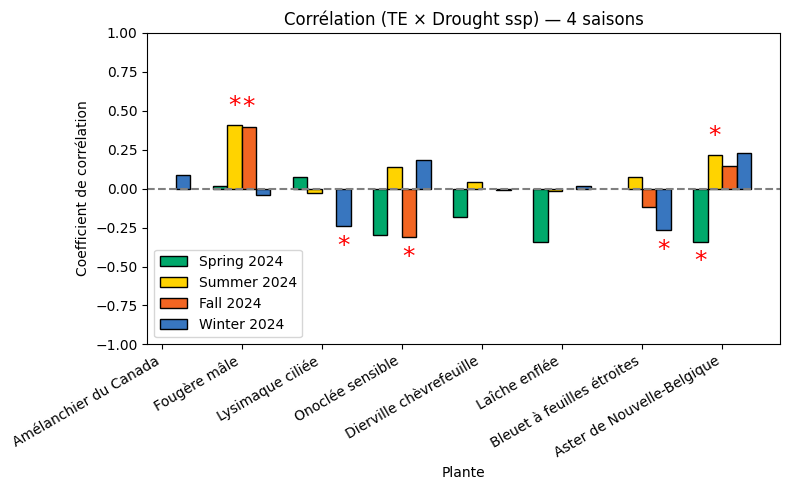

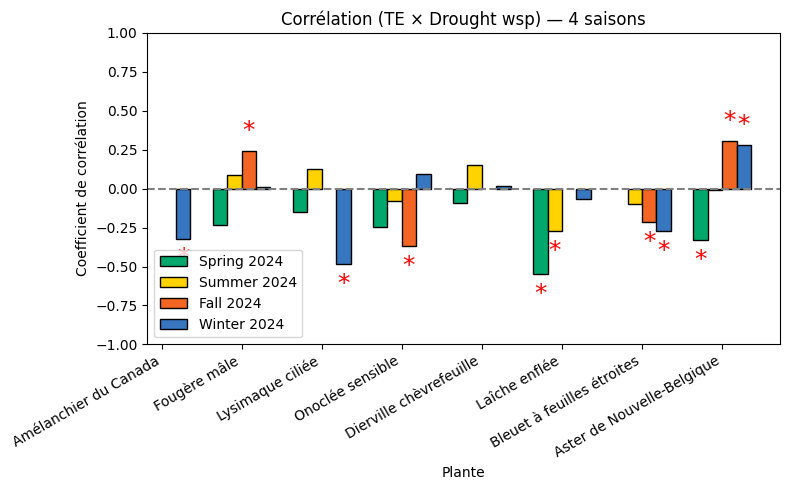

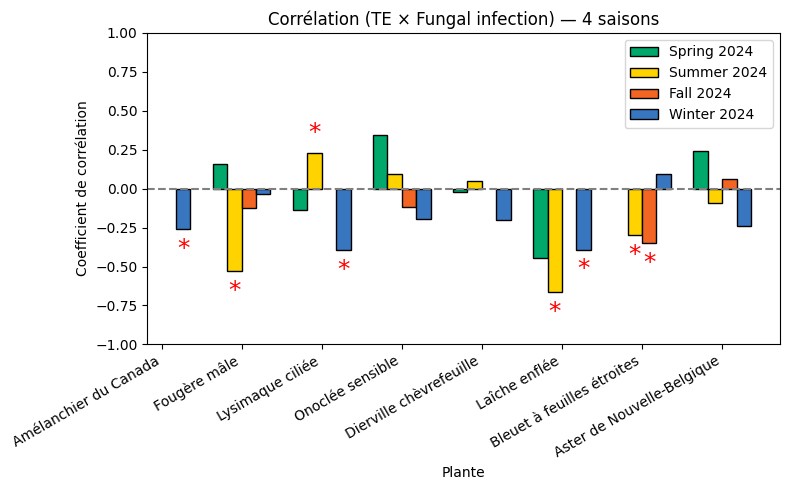

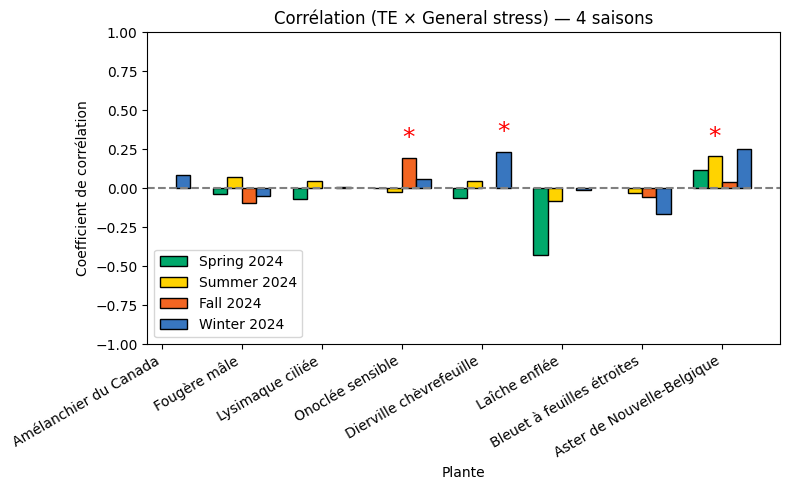

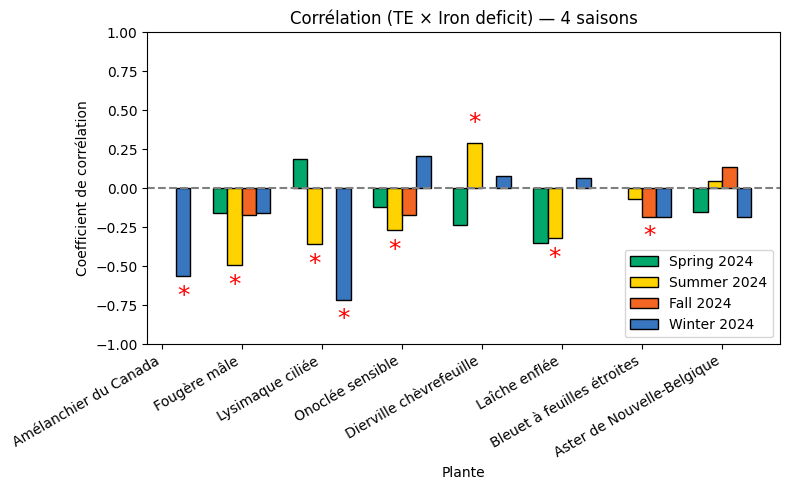

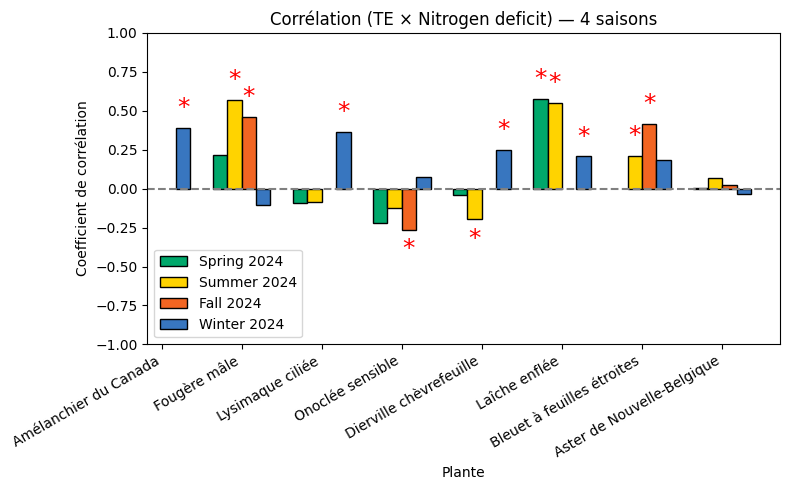

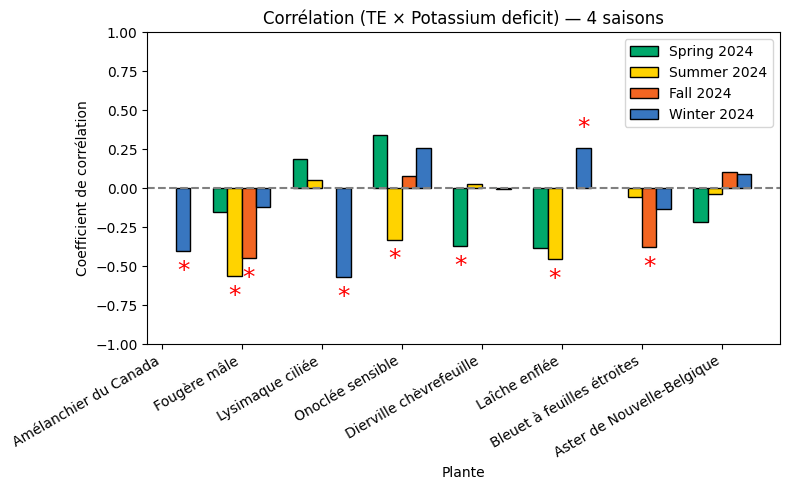

In [198]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# ---- PARAMETERS ---- #
season_order = seasons.values()
if ecosystem == 'GulfStLawrence':
    season_colors = {
        "Winter 2025": "#3876BF",
        "Spring 2024": "#00A86B",
        "Summer 2024": "#FFD300",
        "Fall 2024": "#F26522",
    }
if ecosystem == 'LaurentianMapleGrove':
    season_colors = {
        "Winter 2024": "#3876BF",
        "Spring 2024": "#00A86B",
        "Summer 2024": "#FFD300",
        "Fall 2024": "#F26522",
    }

metrics = [
    "Phosphorus deficit", "Calcium deficit", "Drought h1", "Drought ssp", "Drought wsp",
    "Fungal infection", "General stress", "Iron deficit", "Nitrogen deficit", "Potassium deficit"
]

plant_names = {
    0: 'Amélanchier du Canada',
    1: 'Fougère mâle',
    2: 'Lysimaque ciliée',
    3: 'Onoclée sensible',
    4: 'Dierville chèvrefeuille',
    5: 'Laîche enflée',
    6: 'Bleuet à feuilles étroites',
    7: 'Aster de Nouvelle-Belgique'
}
fixed_plant_order = list(plant_names.keys())
fixed_plant_labels = [plant_names[p] for p in fixed_plant_order]

# ---- CORRELATION PER SEASON ---- #
def compute_corrs_one_season(season, plant_shift=0, method='pearson'):
    te_season = df_all_seasons_combined[df_all_seasons_combined['Season_mapped'] == season].copy()
    te_season["hour"] = te_season["Hour"].round().astype(int)
    print('METRIC', metric)
    te1 = (
        te_season.groupby(['date', 'Plant1', 'hour'])[metric]
        .mean().reset_index().rename(columns={"Plant1": "plant"})
    )
    te2 = (
        te_season.groupby(['date', 'Plant2', 'hour'])[metric]
        .mean().reset_index().rename(columns={"Plant2": "plant"})
    )
    te_hourly = pd.merge(
        te1, te2, on=['date', 'plant', 'hour'], how='outer', suffixes=('_as_plant1', '_as_plant2')
    )
    te_hourly[metric] = te_hourly[[f'{metric}_as_plant1', f'{metric}_as_plant2']].mean(axis=1)
    te_hourly = te_hourly[['date', 'plant', 'hour', metric]]
    df_features = dfs_by_season[season].copy()
    # Ensure plant index is 0-based to match plant_names dict
    df_features['plant'] = df_features['plant'].astype(int) + plant_shift
    te_hourly['plant'] = te_hourly['plant'].astype(int)
    df_features['hour'] = df_features['hour_decimal'].astype(int)
    te_hourly['hour'] = te_hourly['hour'].astype(int)
    df_features['date'] = pd.to_datetime(df_features['date']).dt.date
    te_hourly['date'] = pd.to_datetime(te_hourly['date']).dt.date
    merged = pd.merge(
        df_features,
        te_hourly[['date', 'plant', 'hour', metric]],
        on=['date', 'plant', 'hour']
    )
    corr_results = []
    for plant in fixed_plant_order:  # Always iterate fixed plant order
        plant_data = merged[merged['plant'] == plant]
        for metric_ in metrics:
            sub = plant_data[[metric_, metric]].dropna()
            if len(sub) > 1:
                if method == 'pearson':
                    corr, pval = pearsonr(sub[metric_], sub[metric])
                else:
                    corr, pval = spearmanr(sub[metric_], sub[metric])
            else:
                corr, pval = np.nan, np.nan
            corr_results.append({
                'season': season,
                'plant': plant,
                'plant_name': plant_names.get(plant, str(plant)),
                'metric': metric_,
                'correlation': corr,
                'pval': pval,
                'n_points': len(sub)
            })
    return pd.DataFrame(corr_results)


# ---- COMPUTE ALL SEASONS ---- #
all_corrs = []
for season in season_order:
    all_corrs.append(compute_corrs_one_season(season, plant_shift=0, method='spearman'))
corr_df = pd.concat(all_corrs, ignore_index=True)

# ---- FDR CORRECTION ---- #
corr_df['FDR_reject'], corr_df['pval_FDR'], _, _ = multipletests(
    corr_df['pval'].values, alpha=0.05, method='fdr_bh'
)

# ---- PLOTTING ---- #
def plot_corrs_all_seasons(corr_df, metric, alpha=0.05):
    df_metric = corr_df[corr_df['metric'] == metric].copy()
    x = np.arange(len(fixed_plant_order))
    bar_width = 0.18

    plt.figure(figsize=(8, 5))
    for i, season in enumerate(season_order):
        df_season = df_metric[df_metric['season'] == season].set_index('plant').reindex(fixed_plant_order)
        y = df_season['correlation'].values
        stars = df_season['FDR_reject'].values
        bars = plt.bar(x + i*bar_width - 1.5*bar_width, y,
                       width=bar_width, label=season, color=season_colors[season], edgecolor='k')
        # FDR stars
        for j, bar in enumerate(bars):
            if not np.isnan(bar.get_height()) and stars[j]:
                plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + np.sign(bar.get_height())*0.05,
                         '*', ha='center', va='bottom' if bar.get_height() > 0 else 'top', color='red', fontsize=18)

    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(x, fixed_plant_labels, rotation=30, ha='right')
    plt.ylim(-1, 1)
    plt.ylabel("Coefficient de corrélation")
    plt.xlabel("Plante")
    plt.title(f"Corrélation (TE × {metric}) — 4 saisons")
    plt.legend()
    plt.tight_layout()
    plt.show()

# ---- PLOT ALL FEATURES ---- #
for metric_ in metrics:
    plot_corrs_all_seasons(corr_df, metric_, alpha=0.05)


In [ ]:
seasons

{'Serie 6': 'Spring 2024',
 'Serie 23': 'Summer 2024',
 'Serie 37': 'Fall 2024',
 'Serie 38': 'Winter 2025'}

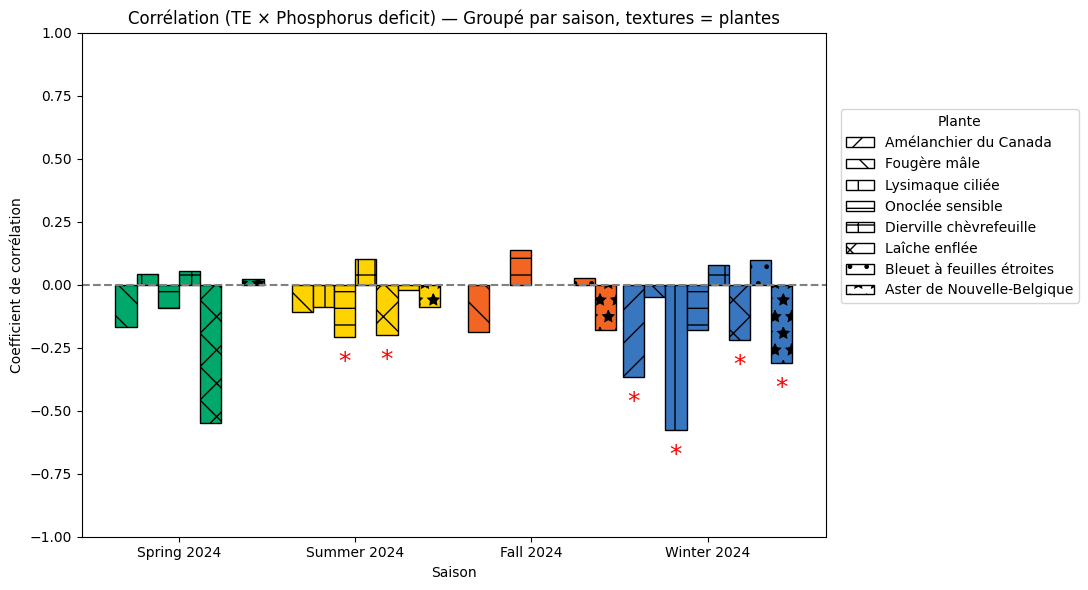

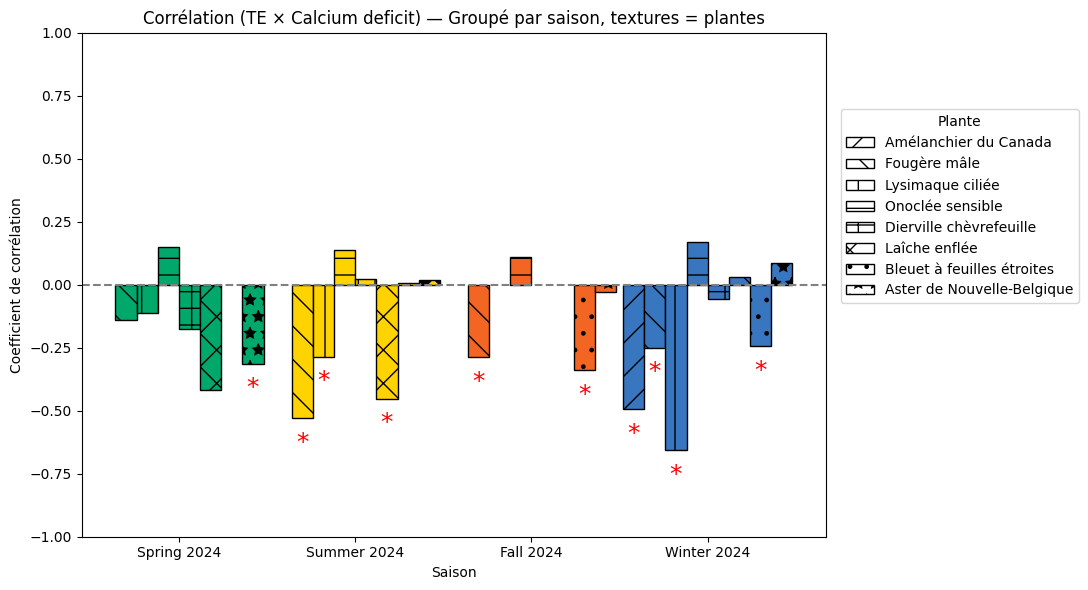

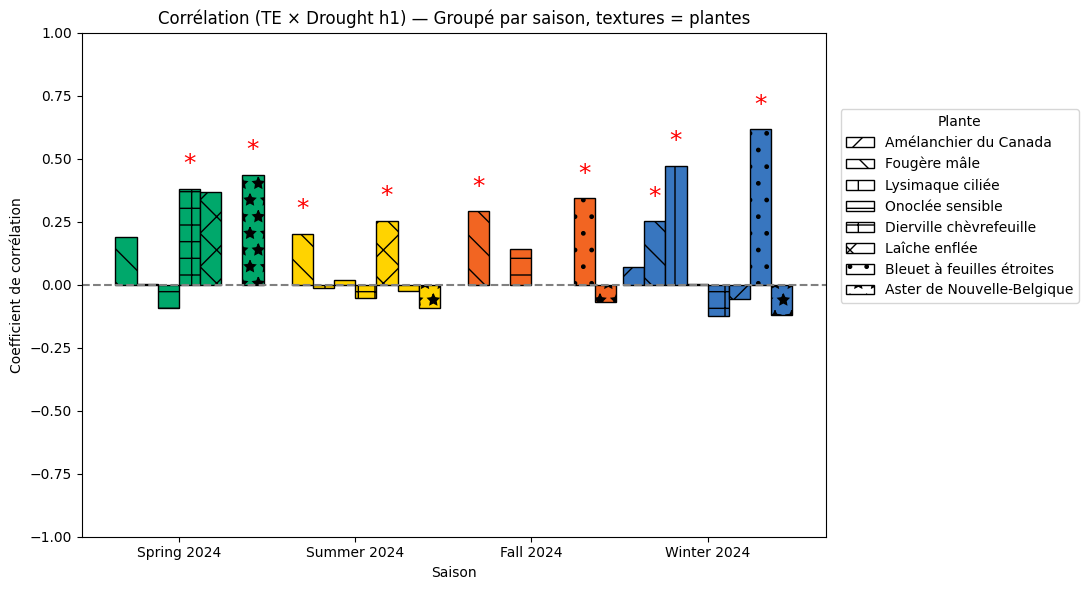

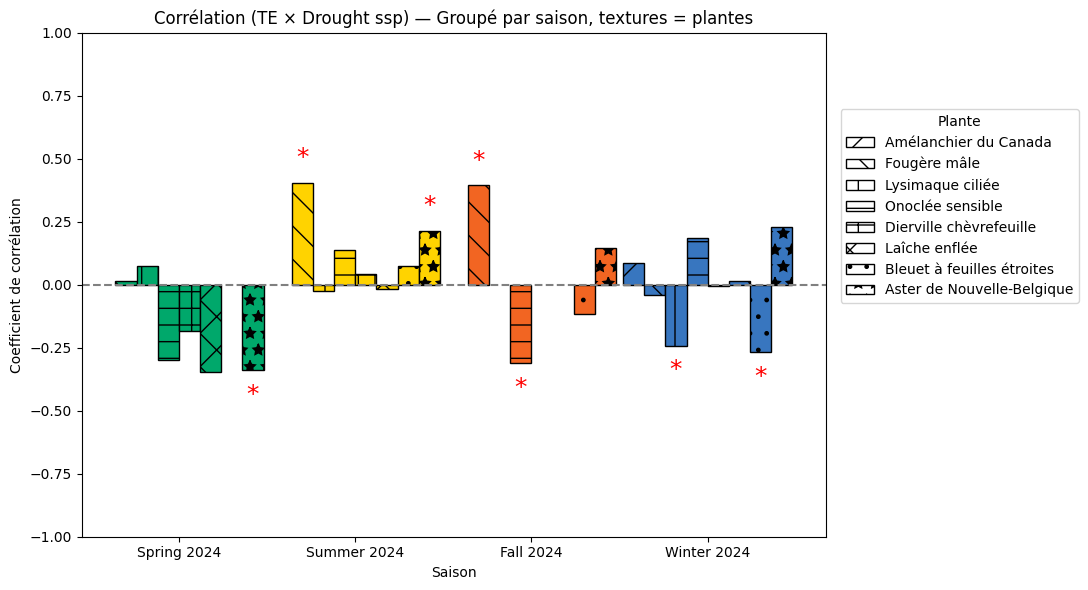

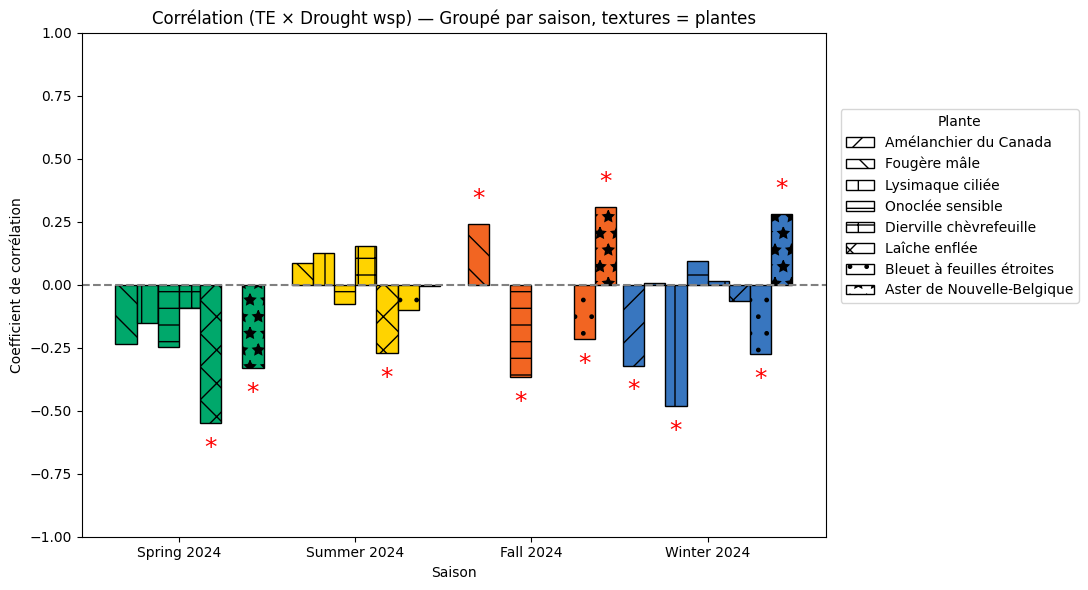

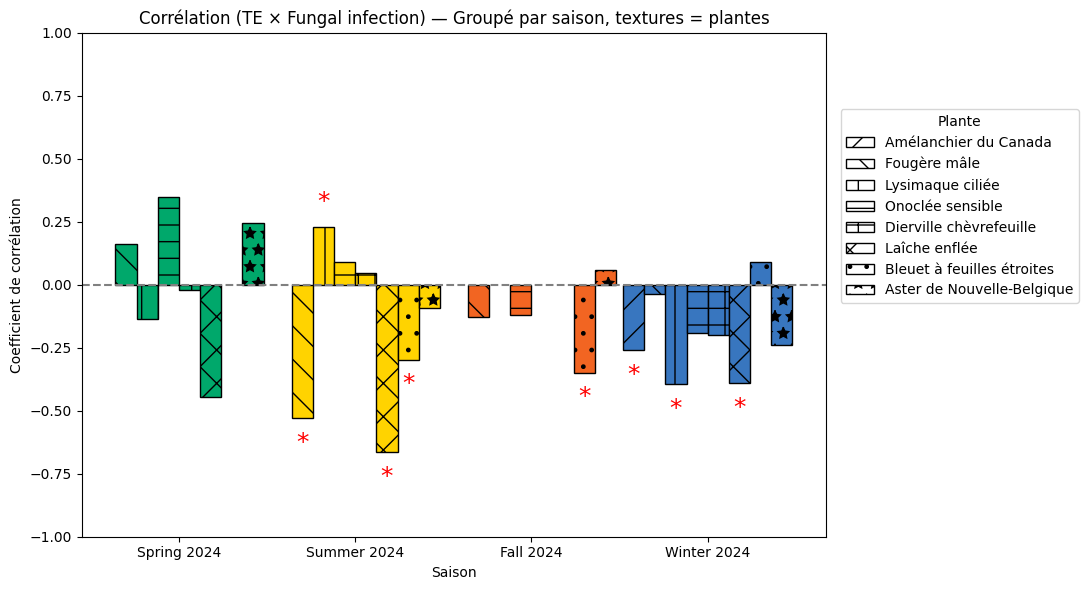

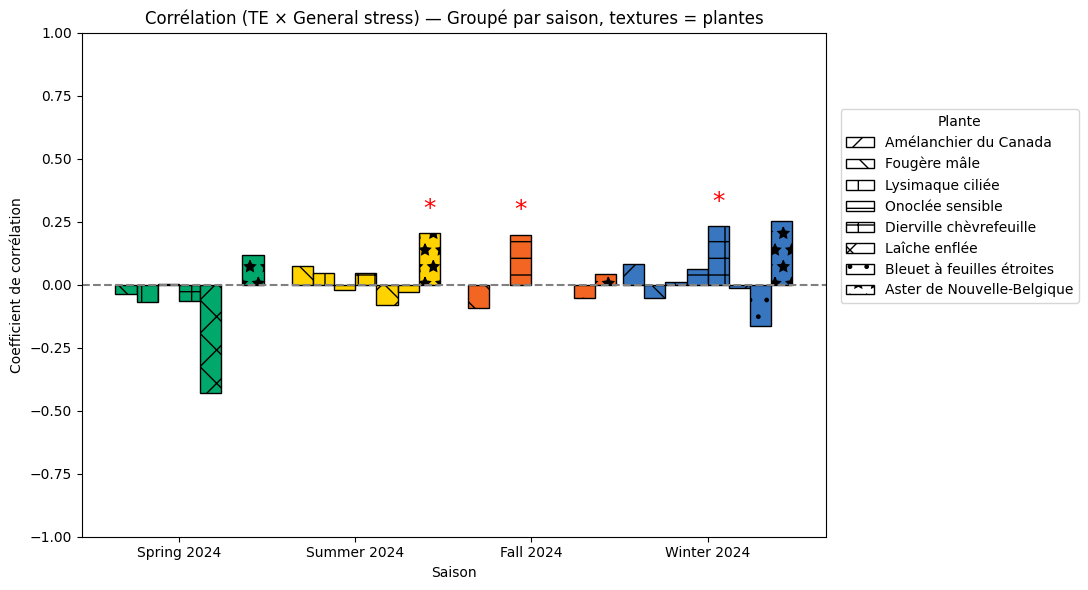

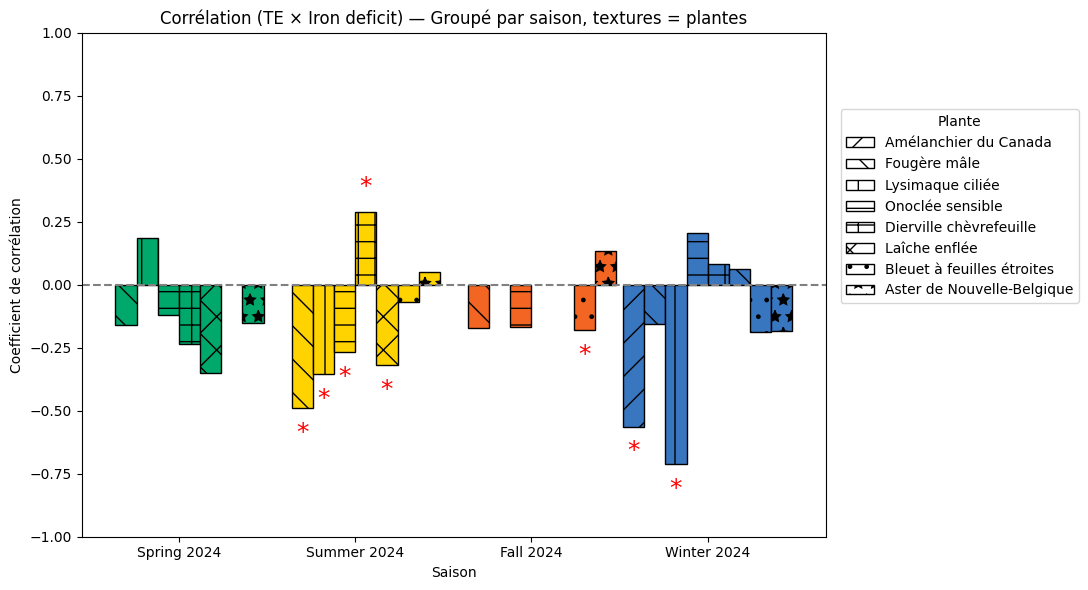

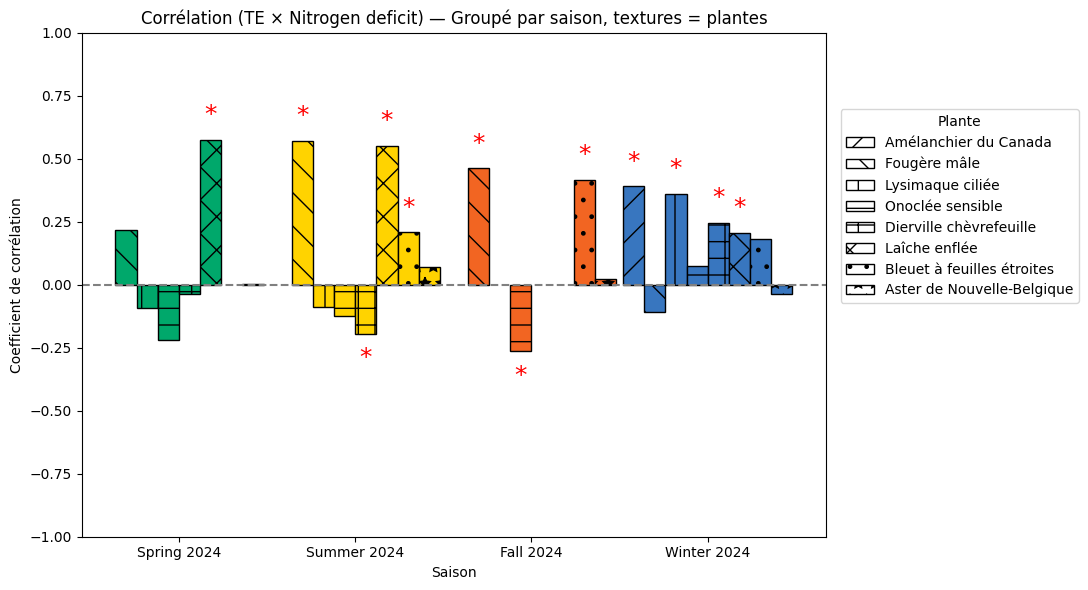

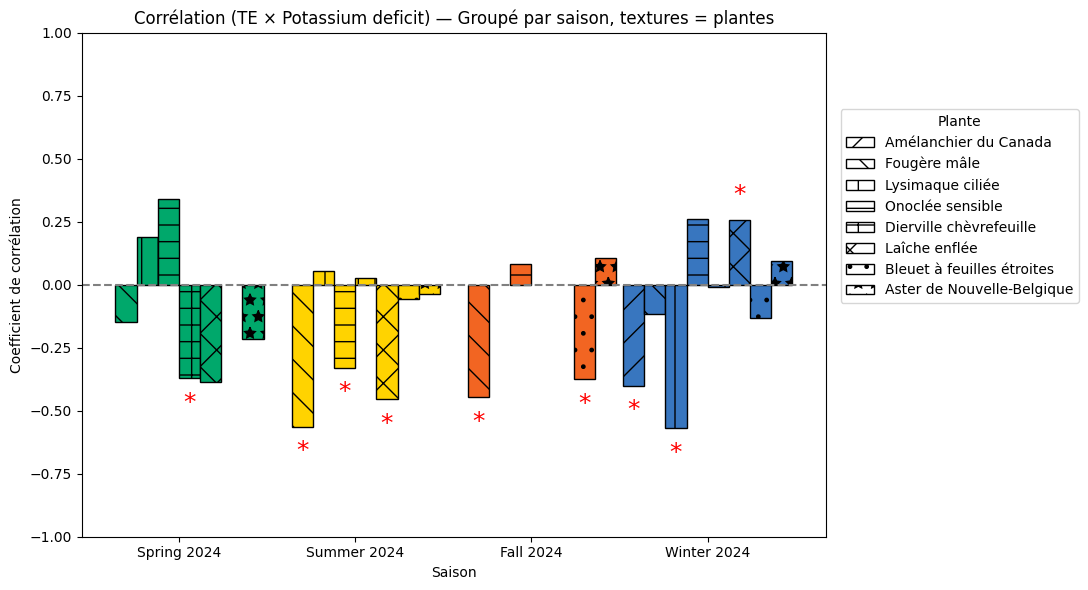

In [200]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import pearsonr, spearmanr
from statsmodels.stats.multitest import multipletests

# ---- PARAMETERS ---- #
season_order = seasons.values()  # ["Winter 2025", "Spring 2024", "Summer 2024", "Fall 2024"]
season_labels = season_order  # For X axis
season_x = np.arange(len(season_order))

# Assign a fixed color per plant (colorblind safe palette)
plant_colors = [
    "#1f77b4", "#ff7f0e", "#2ca02c", "#d62728",  # blue, orange, green, red
    "#9467bd", "#8c564b", "#e377c2", "#7f7f7f"   # purple, brown, pink, gray
]
metrics = [
    "Phosphorus deficit", "Calcium deficit", "Drought h1", "Drought ssp", "Drought wsp",
    "Fungal infection", "General stress", "Iron deficit", "Nitrogen deficit", "Potassium deficit"
]
plant_names = {
    0: 'Amélanchier du Canada',
    1: 'Fougère mâle',
    2: 'Lysimaque ciliée',
    3: 'Onoclée sensible',
    4: 'Dierville chèvrefeuille',
    5: 'Laîche enflée',
    6: 'Bleuet à feuilles étroites',
    7: 'Aster de Nouvelle-Belgique'
}
fixed_plant_order = list(plant_names.keys())
fixed_plant_labels = [plant_names[p] for p in fixed_plant_order]

# ---- CORRELATION PER SEASON ---- #
def compute_corrs_one_season(season, plant_shift=0, method='pearson'):
    te_season = df_all_seasons_combined[df_all_seasons_combined['Season_mapped'] == season].copy()
    te_season["hour"] = te_season["Hour"].round().astype(int)
    te1 = (
        te_season.groupby(['date', 'Plant1', 'hour'])[metric]
        .mean().reset_index().rename(columns={"Plant1": "plant"})
    )
    te2 = (
        te_season.groupby(['date', 'Plant2', 'hour'])[metric]
        .mean().reset_index().rename(columns={"Plant2": "plant"})
    )
    te_hourly = pd.merge(
        te1, te2, on=['date', 'plant', 'hour'], how='outer', suffixes=('_as_plant1', '_as_plant2')
    )
    te_hourly[metric] = te_hourly[[f'{metric}_as_plant1', f'{metric}_as_plant2']].mean(axis=1)
    te_hourly = te_hourly[['date', 'plant', 'hour', metric]]
    df_features = dfs_by_season[season].copy()
    df_features['plant'] = df_features['plant'].astype(int) + plant_shift
    te_hourly['plant'] = te_hourly['plant'].astype(int)
    df_features['hour'] = df_features['hour_decimal'].astype(int)
    te_hourly['hour'] = te_hourly['hour'].astype(int)
    df_features['date'] = pd.to_datetime(df_features['date']).dt.date
    te_hourly['date'] = pd.to_datetime(te_hourly['date']).dt.date
    merged = pd.merge(
        df_features,
        te_hourly[['date', 'plant', 'hour', metric]],
        on=['date', 'plant', 'hour']
    )
    corr_results = []
    for plant in fixed_plant_order:
        plant_data = merged[merged['plant'] == plant]
        for metric_ in metrics:
            sub = plant_data[[metric_, metric]].dropna()
            if len(sub) > 1:
                if method == 'pearson':
                    corr, pval = pearsonr(sub[metric_], sub[metric])
                else:
                    corr, pval = spearmanr(sub[metric_], sub[metric])
            else:
                corr, pval = np.nan, np.nan
            corr_results.append({
                'season': season,
                'plant': plant,
                'plant_name': plant_names.get(plant, str(plant)),
                'metric': metric_,
                'correlation': corr,
                'pval': pval,
                'n_points': len(sub)
            })
    return pd.DataFrame(corr_results)

# ---- COMPUTE ALL SEASONS ---- #
all_corrs = []
for season in season_order:
    all_corrs.append(compute_corrs_one_season(season, plant_shift=0, method='spearman'))
corr_df = pd.concat(all_corrs, ignore_index=True)

# ---- FDR CORRECTION ---- #
corr_df['FDR_reject'], corr_df['pval_FDR'], _, _ = multipletests(
    corr_df['pval'].values, alpha=0.05, method='fdr_bh'
)

plant_hatches = ['/', '\\', '|', '-', '+', 'x', '.', '*']  # One per plant, left-to-right order


def plot_corrs_season_grouped_hatch(corr_df, metric_, alpha=0.05, save=False):
    df_metric = corr_df[corr_df['metric'] == metric_].copy()
    bar_width = 0.12
    n_seasons = len(season_order)
    n_plants = len(fixed_plant_order)
    x = np.arange(len(season_order))  # season group positions

    plt.figure(figsize=(11, 6))
    bar_handles = []

    for j, season in enumerate(season_order):
        y = []
        stars = []
        for i, plant in enumerate(fixed_plant_order):
            row = df_metric[(df_metric['plant'] == plant) & (df_metric['season'] == season)]
            if not row.empty:
                yval = row['correlation'].values[0]
                star = row['FDR_reject'].values[0]
            else:
                yval = np.nan
                star = False
            y.append(yval)
            stars.append(star)
        for i in range(n_plants):
            xpos = x[j] + (i - (n_plants-1)/2)*bar_width
            bar = plt.bar(xpos, y[i], width=bar_width, 
                          color=season_colors[season], 
                          edgecolor='k', 
                          hatch=plant_hatches[i])
            # Save handle for plant legend (first time only)
            if j == 0:
                bar_handles.append(bar)
            # FDR stars
            if not np.isnan(y[i]) and stars[i]:
                plt.text(xpos, y[i] + np.sign(y[i])*0.05, '*',
                         ha='center', va='bottom' if y[i] > 0 else 'top',
                         color='red', fontsize=18)

    plt.axhline(0, color='gray', linestyle='--')
    plt.xticks(x, season_labels)
    plt.ylim(-1, 1)
    plt.ylabel("Coefficient de corrélation")
    plt.xlabel("Saison")
    plt.title(f"Corrélation (TE × {metric_}) — Groupé par saison, textures = plantes")
    
    # Legends: one for season (color), one for plant (hatch)
    from matplotlib.patches import Patch
    season_patches = [Patch(facecolor=season_colors[s], edgecolor='k', label=s) for s in season_order]
    plant_patches = [Patch(facecolor='white', edgecolor='k', hatch=plant_hatches[i], label=fixed_plant_labels[i]) for i in range(n_plants)]
    legend1 = plt.legend(handles=season_patches, title="Saison", loc='upper left', bbox_to_anchor=(1.01, 1))
    #plt.gca().add_artist(legend1)
    plt.legend(handles=plant_patches, title="Plante", loc='lower left', bbox_to_anchor=(1.01, 0.45))
    if save:
        plt.savefig(f'correlation_{metric_}_by_season_grouped_hatch_{ecosystem}.png', bbox_inches='tight')
    plt.tight_layout()
    plt.show()

# ---- PLOT ALL FEATURES ---- #
for metric_ in metrics:
    plot_corrs_season_grouped_hatch(corr_df, metric_, alpha=0.01, save=True)
